<a href="https://colab.research.google.com/github/DJCordhose/buch-machine-learning-notebooks/blob/master/pytorch/kap7-cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kapitel 7: CNNs

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q torchinfo
    !pip install -q torchmetrics

### Die Bilder untersuchen

In [2]:
!curl -O https://raw.githubusercontent.com/DJCordhose/buch-machine-learning-notebooks/master/data/speed-limit-signs.zip
from zipfile import ZipFile
zip_file = ZipFile(r'speed-limit-signs.zip')
zip_file.extractall('.')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1810k  100 1810k    0     0  6643k      0 --:--:-- --:--:-- --:--:-- 6630k


In [3]:
# Bilder untersuchen
from pathlib     import Path
from PIL         import Image
from collections import Counter

dataset_dir = Path("./speed-limit-signs")
sizes       = []

# Alle Bilddateien durchsuchen
for image_path in dataset_dir.rglob("*"):
    if image_path.suffix.lower() in [".png", ".jpg", ".jpeg", ".ppm"]:
        try:
            with Image.open(image_path) as img:
                sizes.append(img.size)  # (Breite, Höhe)
        except Exception as e:
            print(f"Fehler bei {image_path}: {e}")

# Häufigkeiten der Größen zählen
size_counter = Counter(sizes)

print("Gefundene Bildgrößen")
print("--------------------")

for size, count in sorted(size_counter.items()):
    width, height = size
    print(f"{width:>4} x {height:<4} : {count} Bild(er)")

print()
print(f"Insgesamt untersucht: {len(sizes)} Bilder")

Gefundene Bildgrößen
--------------------
  18 x 18   : 1 Bild(er)
  18 x 20   : 1 Bild(er)
  19 x 19   : 2 Bild(er)
  19 x 20   : 2 Bild(er)
  19 x 21   : 1 Bild(er)
  20 x 20   : 4 Bild(er)
  20 x 21   : 1 Bild(er)
  21 x 19   : 1 Bild(er)
  21 x 20   : 2 Bild(er)
  21 x 21   : 7 Bild(er)
  21 x 22   : 1 Bild(er)
  22 x 20   : 1 Bild(er)
  22 x 21   : 3 Bild(er)
  22 x 22   : 5 Bild(er)
  22 x 23   : 5 Bild(er)
  23 x 23   : 7 Bild(er)
  23 x 24   : 2 Bild(er)
  24 x 23   : 1 Bild(er)
  24 x 24   : 8 Bild(er)
  24 x 25   : 2 Bild(er)
  25 x 23   : 1 Bild(er)
  25 x 24   : 4 Bild(er)
  25 x 25   : 12 Bild(er)
  26 x 25   : 1 Bild(er)
  26 x 26   : 7 Bild(er)
  26 x 27   : 3 Bild(er)
  26 x 28   : 1 Bild(er)
  27 x 24   : 1 Bild(er)
  27 x 25   : 1 Bild(er)
  27 x 27   : 8 Bild(er)
  27 x 28   : 3 Bild(er)
  28 x 24   : 1 Bild(er)
  28 x 28   : 6 Bild(er)
  28 x 30   : 1 Bild(er)
  29 x 29   : 9 Bild(er)
  29 x 30   : 1 Bild(er)
  29 x 31   : 2 Bild(er)
  30 x 28   : 1 Bild(er)
  30 x 

### Das Netzwerk definieren

In [4]:
# Netzwerk definieren
# Diesmal mit Dropouts!
import torch
import torch.nn as nn
import torch.nn.functional as F

class TrafficSignCNN(nn.Module):
    # Anzahl der Klassen und Dropout-Wert festlegen:
    def __init__(self, num_classes=6, drop_out=0.6):
        super().__init__()

        # Feature Detection:
        self.features = nn.Sequential(
            # Ein Block mit Convolutional Layers
            nn.Conv2d( 3, 64, 3, 1, 1), nn.ReLU(),   # in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1,
            nn.Conv2d(64, 64, 3, 1, 1), nn.ReLU(),   # in_channels=64, out_channels=64, ...
            nn.Conv2d(64, 64, 3, 1, 1), nn.ReLU(),   # in_channels=64, out_channels=64, ...
            nn.MaxPool2d(kernel_size=2),             # Größe Feature Channels auf 32 x 32 halbieren
            nn.Dropout(drop_out),

            # noch ein Block
            nn.Conv2d( 64, 128, 3, 1, 1), nn.ReLU(), # in_channels=64, out_channels=128
            nn.Conv2d(128, 128, 3, 1, 1), nn.ReLU(), # in_channels=128, out_channels=128
            nn.MaxPool2d(kernel_size=2),             # Größe Feature Channels auf 16 x 16 halbieren
            nn.Dropout(drop_out),

            # und ein weiterer Block
            nn.Conv2d(128, 256, 3, 1, 1), nn.ReLU(), # in_channels=128, out_channels=256
            nn.MaxPool2d(kernel_size=2),             # Größe Feature Channels auf 8 x 8 halbieren
            nn.Dropout(drop_out),
        )

        # Klassifizierung:
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),             # in_channels=16.384, out_channels=256
            nn.ReLU(),
            nn.Dropout(drop_out),
            nn.Linear(256, num_classes)              # in_channels=256, out_channels=6 (Logits = categories)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# 'device' bezeichnet das Gerät - den sogenannten Beschleuniger (Accelerator),
# auf dem die Berechnungen ausgeführt werden. Das kann z. B. eine GPU,
# spezielle Rechenkerne in Apple-Silicon-Prozessoren oder ein Server
# in der Cloud sein.
#
# Modell, Eingabedaten und andere Tensoren müssen dafür auf dieses device
# verschoben werden.
# Das geschieht weiter unten zum Beispiel mit
# model.to(device)

# Beschleuniger wählen:
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type

# nichts gefunden, also CPU verwenden.
# Langsam, aber immerhin möglich.
else:
    device = 'cpu'


### Modellzusammenfassung ausgeben

In [5]:
# Modellarchitektur ausgeben
# see: https://pypi.org/project/torchinfo/
# see: https://github.com/tyleryep/torchinfo
from torchinfo import summary

# Modell erzeugen
model = TrafficSignCNN(num_classes=6)

# Ausgabe:
print(
    summary(
        model,
        input_size=(32, 3, 64, 64), # Batchgröße, Farbkanäle, Höhe, Breite
        # col_names=("input_size", "output_size", "num_params"),
        col_names=("output_size", "num_params"),
    )
)

Layer (type:depth-idx)                   Output Shape              Param #
TrafficSignCNN                           [32, 6]                   --
├─Sequential: 1-1                        [32, 256, 8, 8]           --
│    └─Conv2d: 2-1                       [32, 64, 64, 64]          1,792
│    └─ReLU: 2-2                         [32, 64, 64, 64]          --
│    └─Conv2d: 2-3                       [32, 64, 64, 64]          36,928
│    └─ReLU: 2-4                         [32, 64, 64, 64]          --
│    └─Conv2d: 2-5                       [32, 64, 64, 64]          36,928
│    └─ReLU: 2-6                         [32, 64, 64, 64]          --
│    └─MaxPool2d: 2-7                    [32, 64, 32, 32]          --
│    └─Dropout: 2-8                      [32, 64, 32, 32]          --
│    └─Conv2d: 2-9                       [32, 128, 32, 32]         73,856
│    └─ReLU: 2-10                        [32, 128, 32, 32]         --
│    └─Conv2d: 2-11                      [32, 128, 32, 32]         147

### Die Bilder laden und vorverarbeiten

In [6]:
# Bilder laden und für das Training vorbereiten
from torchvision.datasets    import ImageFolder      # liest Bilder und Labels aus Ordnern
from torchvision.transforms  import v2               # Bildvorverarbeitung
from torch.utils.data        import DataLoader       # liefert Samples später in Batches
from torch.utils.data        import Subset           # erzeugt daraus später zwei Teildatensätze
from sklearn.model_selection import train_test_split # sorgt für die zufällige Aufteilung der Daten

dataset_dir = "./speed-limit-signs/"

label_names = { 0: "30", 1:  "50", 2:  "70",
                3: "80", 4: "100", 5: "120",}

# Vorverarbeitung für jedes Bild definieren
transform = v2.Compose([
    v2.ToImage(),                              # PIL-Bild -> Image-Tensor
    v2.Resize((64, 64)),                       # einheitliche Bildgröße
    v2.ToDtype(torch.float32, scale=True),     # Wertebereich 0..255 -> 0..1
])

# Datensatz aus Ordnerstruktur erzeugen.
# ImageFolder nutzt die Unterordner als Klassen.
dataset = ImageFolder(
    root=dataset_dir,
    transform=transform
)

# Indizes der Einträge
indices = list(range(len(dataset)))

random_state    = 42   # Damit der Zufall reproduzierbar wird.
tmp_test_split  = 0.2  # Wiviele Daten werden als Testdaten verwendet? 0.2 = 20%
train_val_split = 0.3  # Wieviel Prozent davon für die Validierung?

# Daten in temporäre und Testdaten splitten
tmp_idx, test_idx = train_test_split(
    indices,
    test_size=tmp_test_split,  #
    random_state=random_state, # reproduzierbarer Zufall
    stratify=dataset.targets   # gleichmäßige Verteilung der Klassen erzwingen
)

# tmp_idx in Trainings- und Validierungsdaten aufteilen:
train_idx, val_idx = train_test_split(
    tmp_idx,
    test_size=train_val_split, # Training: 70%, Validierung: 30% der temporären Indizes
    random_state=random_state, # reproduzierbarer Zufall
)

train_dataset = Subset(dataset, train_idx) # Trainingsdaten auf Basis ihrer Indizes
val_dataset   = Subset(dataset, val_idx)   # Validierungsdaten auf Basis ihrer Indizes
test_dataset  = Subset(dataset, test_idx)  # Testdaten auf Basis ihrer Indizes

# DataLoader definieren
# 1. Trainingsdaten
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

# 2. Validierungsdaten
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
)

# 3. Testdaten
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)


### Bericht über Datenvorbereitung

In [7]:
# Reporting über Datenvorbereitung:
print(
f"Geladener Datensatz\n",
f"-------------------\n",
f"Ordner: {dataset_dir}\n",
f"Anzahl Bilder insgesamt: {len(dataset)}\n",
f"Gefundene Klassenordner: {dataset.classes}\n",
f"Zuordnung Ordnername -> Klassen-ID: {dataset.class_to_idx}\n\n",
f"Bedeutung der Labels\n",
)
for class_id, label in label_names.items():
    print(f"{class_id}: {label}")
print()

print(
f"Aufteilung in Trainings- und Testdaten\n",
f"--------------------------------------\n",
f"Trainingsdaten:    {len(train_dataset)} Bilder\n",
f"Validierungsdaten: {len(val_dataset)} Bilder\n",
f"Testdaten:         {len(test_dataset)} Bilder\n",
)

def describe_split(name, dataset):
    image, label = dataset[0]

    images_shape = (len(dataset),) + tuple(image.shape)
    labels_shape = (len(dataset),)

    # Bei Subset liegt das eigentliche ImageFolder-Dataset in dataset.dataset
    base_dataset = dataset.dataset if hasattr(dataset, "dataset") else dataset
    num_classes = len(base_dataset.classes)

    print(f"{name}:")
    print(f"  Bilder: {images_shape}")
    print(f"  Labels: {labels_shape}")
    print(f"  Kategorien: {num_classes}")
    # print(f"  Beispielbild: {image.shape}")
    # print(f"  Beispiellabel: {label}")
    print()

describe_split("Training", train_dataset)
describe_split("Validierung", val_dataset)
describe_split("Test", test_dataset)

Geladener Datensatz
 -------------------
 Ordner: ./speed-limit-signs/
 Anzahl Bilder insgesamt: 379
 Gefundene Klassenordner: ['0', '1', '2', '3', '4', '5']
 Zuordnung Ordnername -> Klassen-ID: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}

 Bedeutung der Labels

0: 30
1: 50
2: 70
3: 80
4: 100
5: 120

Aufteilung in Trainings- und Testdaten
 --------------------------------------
 Trainingsdaten:    212 Bilder
 Validierungsdaten: 91 Bilder
 Testdaten:         76 Bilder

Training:
  Bilder: (212, 3, 64, 64)
  Labels: (212,)
  Kategorien: 6

Validierung:
  Bilder: (91, 3, 64, 64)
  Labels: (91,)
  Kategorien: 6

Test:
  Bilder: (76, 3, 64, 64)
  Labels: (76,)
  Kategorien: 6



### Trainingsschleife

In [8]:
%%time

import torch
from torch                       import nn, optim
from torchmetrics.classification import Accuracy

accuracy = Accuracy(
    task="multiclass",
    num_classes=6
).to(device)

# Modell auf Beschleuniger verschieben
model = model.to(device)

# Loss- und Optimierungsfunktion definieren
loss_fn    = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=1e-3)

# Wiederholungen
num_epochs = 500

# Speicher für Statistiken und Berichte
train_losses     = []
train_accuracies = []
val_losses       = []
val_accuracies   = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch} / {num_epochs}")
    # Training
    model.train()
    accuracy.reset()

    # Startwerte initialisieren
    loss_total = 0.0
    total      = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss   = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        loss_total += loss.item() * batch_size
        total += batch_size

        accuracy.update(logits, labels)

    train_loss = loss_total / total
    train_acc  = accuracy.compute().cpu().item()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validierung
    model.eval()
    accuracy.reset()

    loss_total = 0.0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = loss_fn(logits, labels)

            batch_size = labels.size(0)
            loss_total += loss.item() * batch_size
            total += batch_size

            accuracy.update(logits, labels)

    val_loss = loss_total / total
    val_acc = accuracy.compute().cpu().item()

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
Epoch 51
Epoch 52
Epoch 53
Epoch 54
Epoch 55
Epoch 56
Epoch 57
Epoch 58
Epoch 59
Epoch 60
Epoch 61
Epoch 62
Epoch 63
Epoch 64
Epoch 65
Epoch 66
Epoch 67
Epoch 68
Epoch 69
Epoch 70
Epoch 71
Epoch 72
Epoch 73
Epoch 74
Epoch 75
Epoch 76
Epoch 77
Epoch 78
Epoch 79
Epoch 80
Epoch 81
Epoch 82
Epoch 83
Epoch 84
Epoch 85
Epoch 86
Epoch 87
Epoch 88
Epoch 89
Epoch 90
Epoch 91
Epoch 92
Epoch 93
Epoch 94
Epoch 95
Epoch 96
Epoch 97
Epoch 98
Epoch 99
Epoch 100
Epoch 101
Epoch 102
Epoch 103
Epoch 104
Epoch 105
Epoch 106
Epoch 107
Epoch 108
Epoch 109
Epoch 110


### Verifizierung mit den Testdaten

In [9]:
# Bewertung auf den Testdaten
import numpy as np

loss_fn_per_sample = torch.nn.CrossEntropyLoss(reduction="none")

model.eval()

test_losses_per_sample = []
test_correct_per_sample = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        losses = loss_fn_per_sample(logits, labels)
        predictions = logits.argmax(dim=1)
        correct = predictions == labels

        test_losses_per_sample.extend(losses.cpu().tolist())
        test_correct_per_sample.extend(correct.cpu().tolist())

test_accuracy_running = np.cumsum(test_correct_per_sample) / np.arange(
    1, len(test_correct_per_sample) + 1
)

test_loss = np.mean(test_losses_per_sample)
test_accuracy = np.mean(test_correct_per_sample)

test_loss, test_accuracy

(np.float64(0.3827684985807399), np.float64(0.9868421052631579))

### Berichte nach dem Training erzeugen und ausgeben

Epoch 1: 
    Train Loss:          1.7829
    Train Accuracy:      0.1745
    Validation Loss:     0.0175
    Validation Accuracy: 0.1978

Epoch 2: 
    Train Loss:          1.7356
    Train Accuracy:      0.2123
    Validation Loss:     0.0175
    Validation Accuracy: 0.3077

Epoch 3: 
    Train Loss:          1.7124
    Train Accuracy:      0.2075
    Validation Loss:     0.0175
    Validation Accuracy: 0.2198

Epoch 4: 
    Train Loss:          1.7050
    Train Accuracy:      0.2547
    Validation Loss:     0.0175
    Validation Accuracy: 0.1978

Epoch 5: 
    Train Loss:          1.6784
    Train Accuracy:      0.3019
    Validation Loss:     0.0175
    Validation Accuracy: 0.2088

Epoch 6: 
    Train Loss:          1.6654
    Train Accuracy:      0.2500
    Validation Loss:     0.0175
    Validation Accuracy: 0.1978

Epoch 7: 
    Train Loss:          1.6332
    Train Accuracy:      0.2877
    Validation Loss:     0.0175
    Validation Accuracy: 0.2198

Epoch 8: 
    Train Loss:  

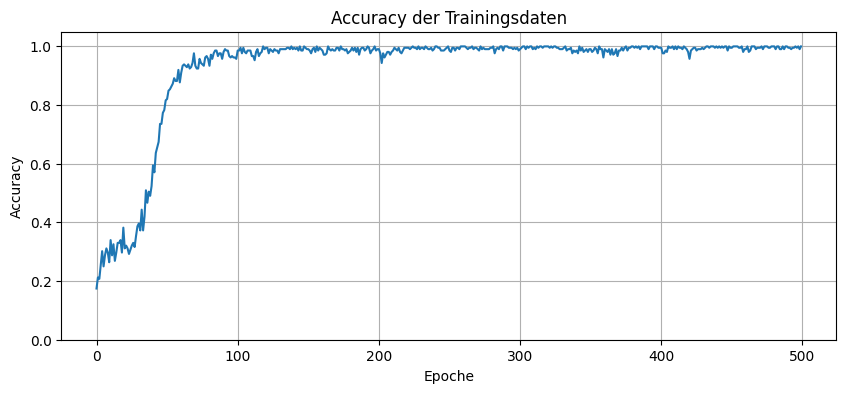

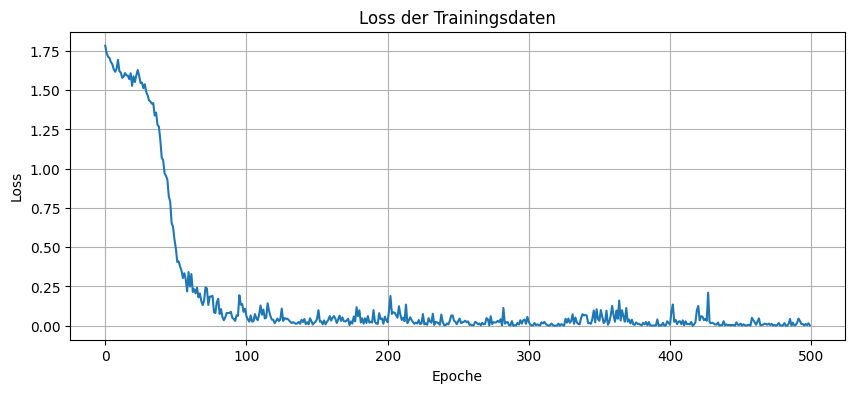

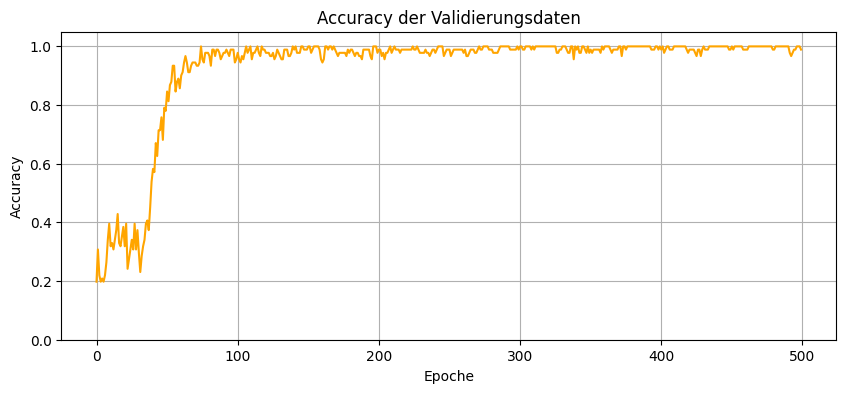

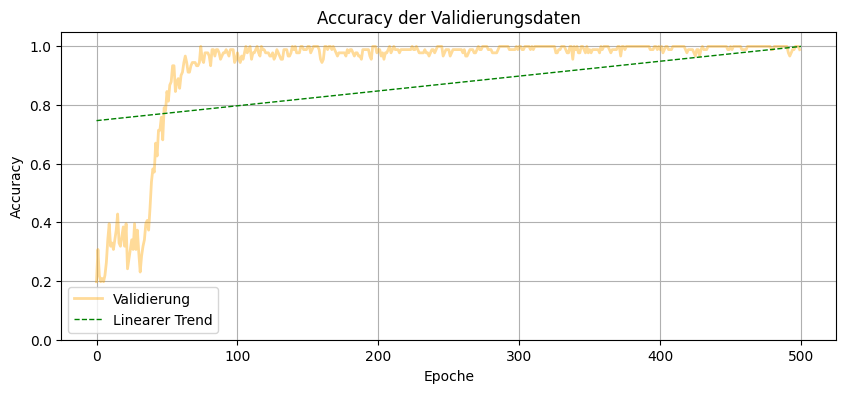

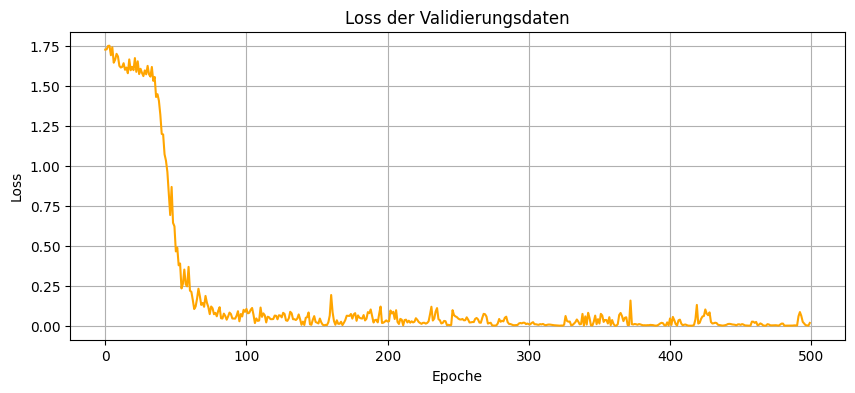

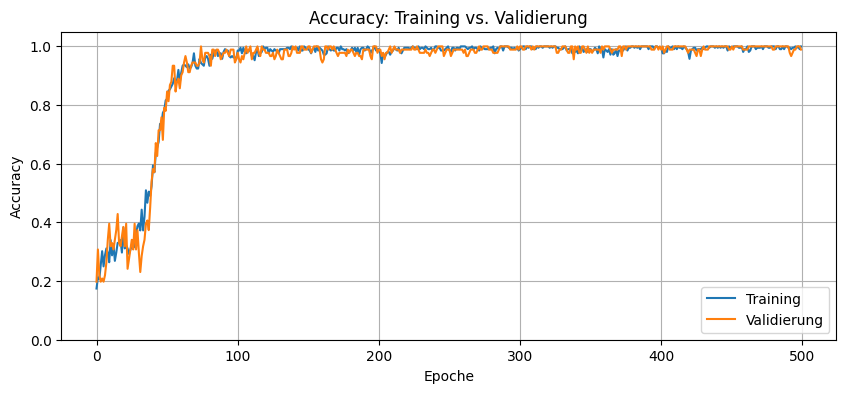

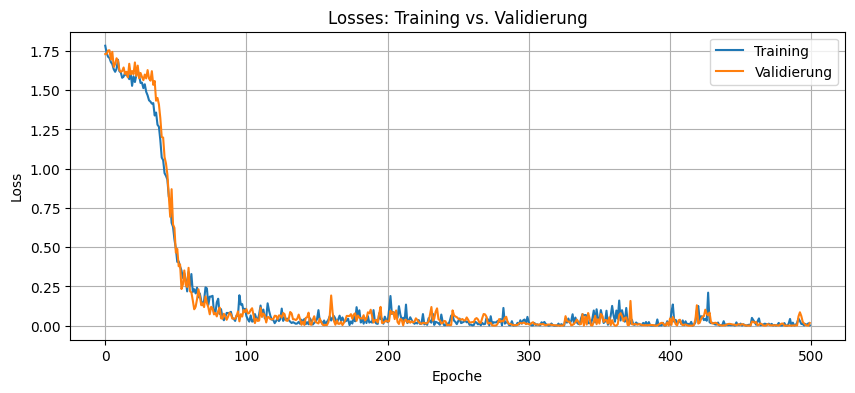

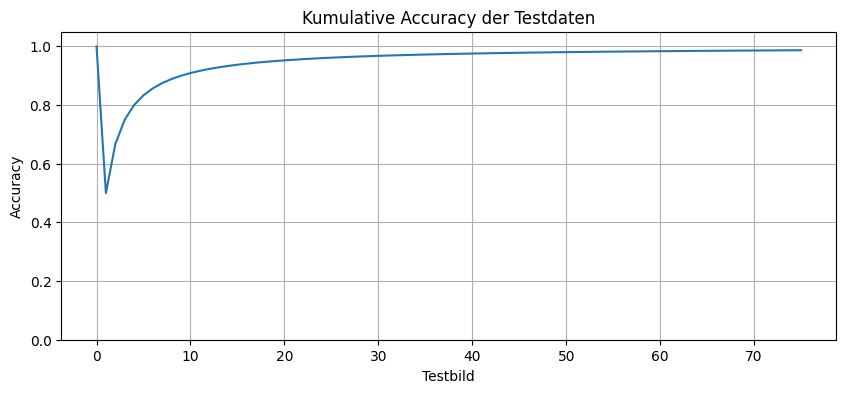

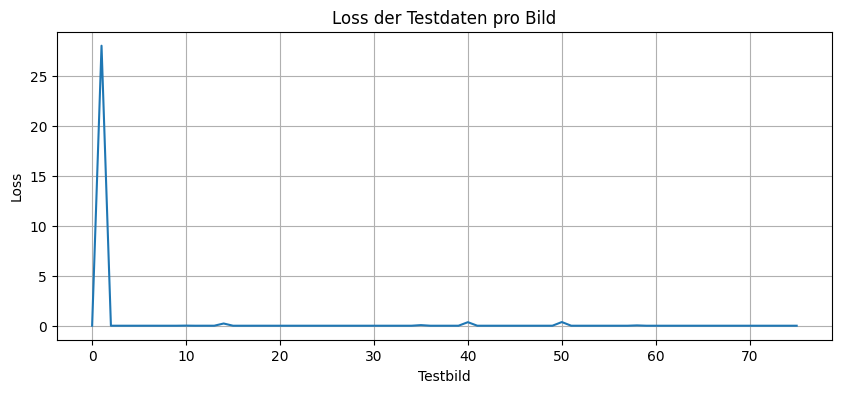

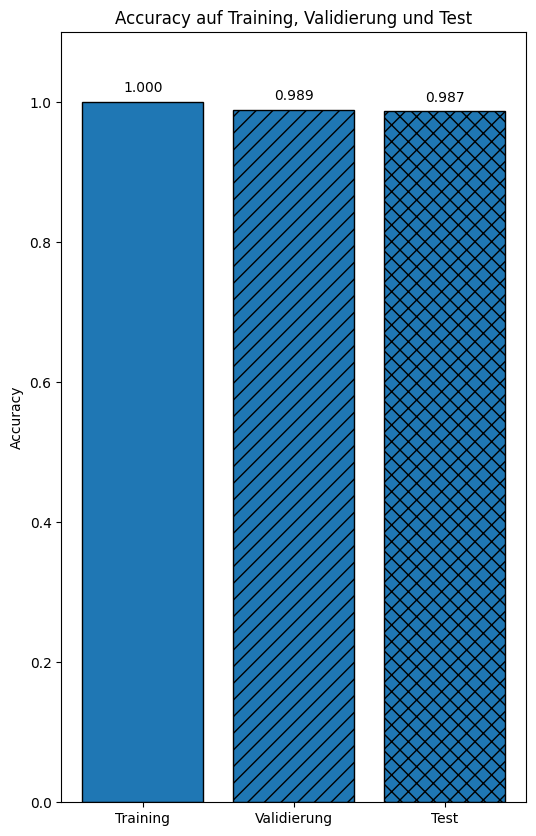

In [10]:
# Reporting nach dem Training
import matplotlib.pyplot as plt
import numpy as np

for i in range(num_epochs):
    print(
        f"Epoch {i + 1}: \n"
        f"    Train Loss:          {train_losses[i]:.4f}\n"
        f"    Train Accuracy:      {train_accuracies[i]:.4f}\n"
        f"    Validation Loss:     {val_loss:.4f}\n"
        f"    Validation Accuracy: {val_accuracies[i]:.4f}\n"
    )

# 1. Accuracy der Trainingsdaten
plt.figure(figsize=(10, 4))
plt.plot(train_accuracies)
plt.title("Accuracy der Trainingsdaten")
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()


# 2. Loss der Trainingsdaten
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.title("Loss der Trainingsdaten")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# 3. Accuracy der Validierungsdaten
plt.figure(figsize=(10, 4))
plt.plot(val_accuracies, color="orange")
plt.title("Accuracy der Validierungsdaten")
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()
###
window = 15

val_acc_smooth = np.convolve(
    val_accuracies,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 4))

# Hauptlinie
plt.plot(
    val_accuracies,
    color="orange",
    linewidth=2,
    alpha=0.4,
    label="Validierung"
)

epochs = np.arange(len(val_accuracies))  # 0 bis 499

m, b = np.polyfit(epochs, val_accuracies, deg=1)

trend_x = np.array([0, 500])
trend_y = m * trend_x + b
trend_y = np.clip(trend_y, 0, 1)  # Accuracy auf gültigen Bereich begrenzen

plt.plot(
    trend_x,
    trend_y,
    color="green",
    linewidth=1,
    linestyle="--",
    label="Linearer Trend"
)

plt.title("Accuracy der Validierungsdaten")
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()
####

# 4. Loss der Vailiderungsdaten:
plt.figure(figsize=(10, 4))
plt.plot(val_losses, color="orange")
plt.title("Loss der Validierungsdaten")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# 5. Accuracy: Training vs. Validierung
plt.figure(figsize=(10, 4))
plt.plot(train_accuracies, label="Training")
plt.plot(val_accuracies, label="Validierung")
plt.title("Accuracy: Training vs. Validierung")
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

# 6. Loss: Training vs. Validierung
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Training")
plt.plot(val_losses, label="Validierung")
plt.title("Losses: Training vs. Validierung")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# 7. Accuracy der Testdaten
plt.figure(figsize=(10, 4))
plt.plot(test_accuracy_running)
plt.title("Kumulative Accuracy der Testdaten")
plt.xlabel("Testbild")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

# 8. Loss der Testdaten
plt.figure(figsize=(10, 4))
plt.plot(test_losses_per_sample)
plt.title("Loss der Testdaten pro Bild")
plt.xlabel("Testbild")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# 9. Mal sehen....
labels = ["Training", "Validierung", "Test"]
values = [train_accuracies[-1], val_accuracies[-1], test_accuracy]
hatches = ["", "//", "xx"]

fig, ax = plt.subplots(figsize=(6, 10))  # höheres Diagramm streckt y-Achse optisch

bars = ax.bar(labels, values, edgecolor="black")

for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy auf Training, Validierung und Test")

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.show()


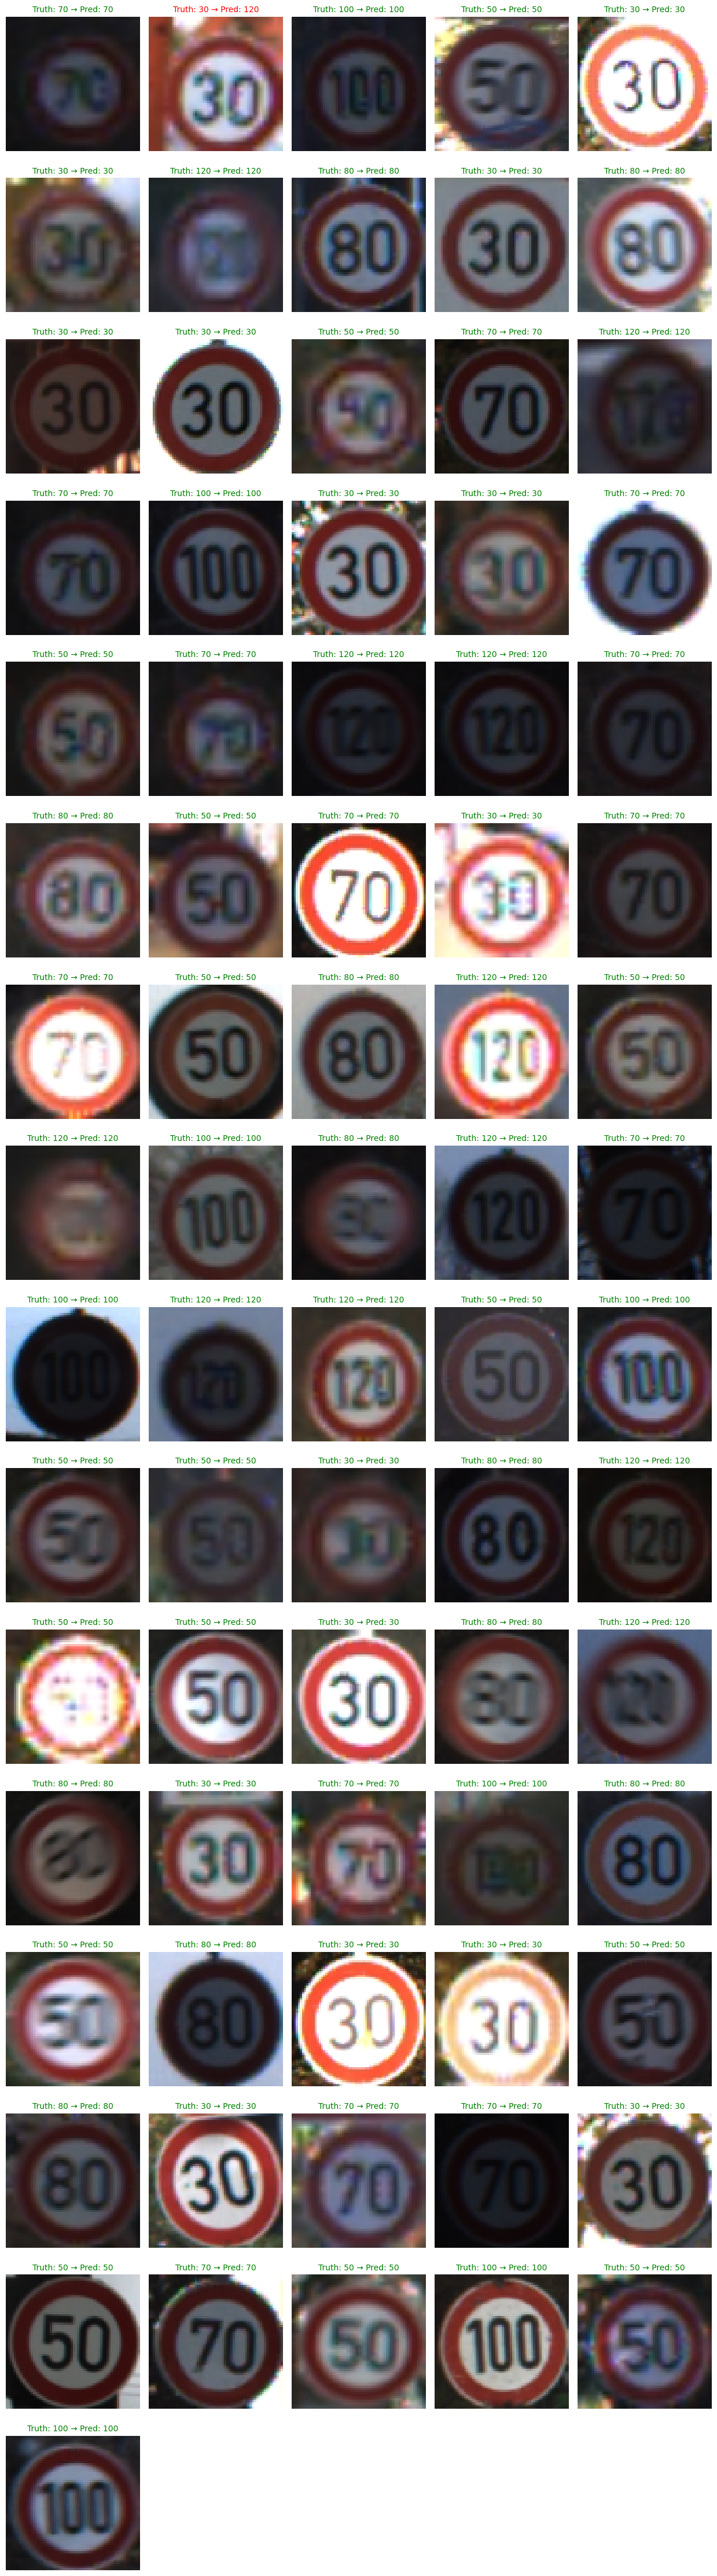

In [11]:
# Visuelle Bestätigung
import math
import matplotlib.pyplot as plt
import torch

def show_test_predictions(model, test_dataset, device, label_names, n="all", cols=5):
    model.eval()

    if n == "all":
        n = len(test_dataset)

    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 2.5, rows * 2.8))

    with torch.no_grad():
        for i in range(n):
            image, truth = test_dataset[i]

            logits = model(image.unsqueeze(0).to(device))
            prediction = logits.argmax(dim=1).item()

            color = "green" if truth == prediction else "red"

            plt.subplot(rows, cols, i + 1)
            plt.imshow(image.permute(1, 2, 0).cpu())
            plt.axis("off")
            plt.title(
                f"Truth: {label_names[truth]} → Pred: {label_names[prediction]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()


show_test_predictions(
    model=model,
    test_dataset=test_dataset,
    device=device,
    label_names=label_names,
    n="all",
    cols=5
)